In [15]:
import pandas as pd
print("Pandas installed ✅")


Pandas installed ✅


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Loaded ✅")

Libraries Loaded ✅


In [17]:
# Load only 100k rows for fast execution
df = pd.read_csv("Fraud.csv", nrows=100000)

print("Dataset Loaded ✅")
df.head()

Dataset Loaded ✅


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [18]:
df.info()
print("\nMissing Values:\n", df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            100000 non-null  int64  
 1   type            100000 non-null  str    
 2   amount          100000 non-null  float64
 3   nameOrig        100000 non-null  str    
 4   oldbalanceOrg   100000 non-null  float64
 5   newbalanceOrig  100000 non-null  float64
 6   nameDest        100000 non-null  str    
 7   oldbalanceDest  100000 non-null  float64
 8   newbalanceDest  100000 non-null  float64
 9   isFraud         100000 non-null  int64  
 10  isFlaggedFraud  100000 non-null  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 8.4 MB

Missing Values:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: 

In [19]:
# Drop unnecessary columns
df = df.drop(['nameOrig', 'nameDest'], axis=1)

# Convert categorical to numeric
df = pd.get_dummies(df, columns=['type'], drop_first=True)

print("Data Cleaning Done ✅")

Data Cleaning Done ✅


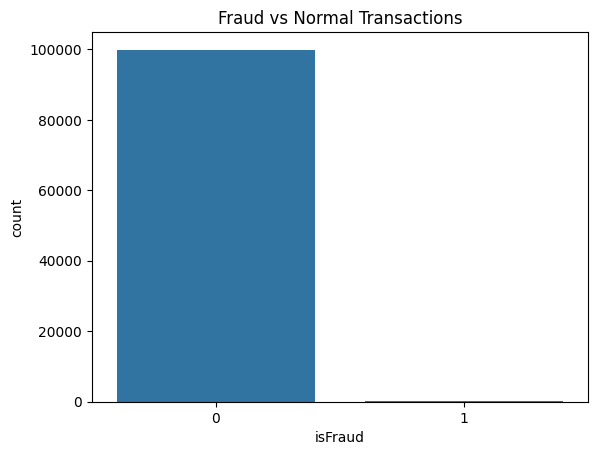

In [20]:
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

In [21]:
from sklearn.model_selection import train_test_split

X = df.drop('isFraud', axis=1)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data Split Done ✅")

Data Split Done ✅


In [22]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

print("Model Trained ✅")

Model Trained ✅


In [23]:
y_pred = model.predict(X_test)

print("Prediction Done ✅")

Prediction Done ✅


In [24]:
from sklearn.metrics import classification_report

print("Model Performance:\n")
print(classification_report(y_test, y_pred))

Model Performance:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19978
           1       1.00      0.59      0.74        22

    accuracy                           1.00     20000
   macro avg       1.00      0.80      0.87     20000
weighted avg       1.00      1.00      1.00     20000



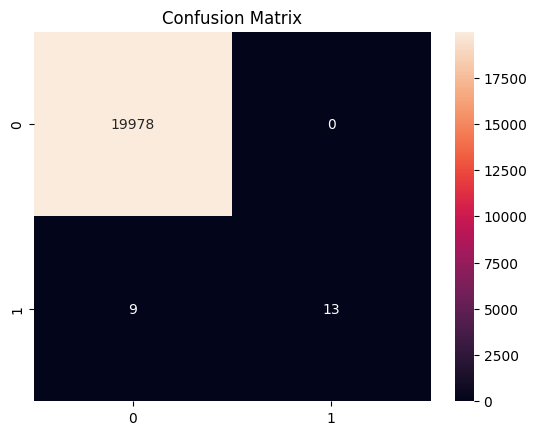

In [25]:
from sklearn.metrics import confusion_matrix

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

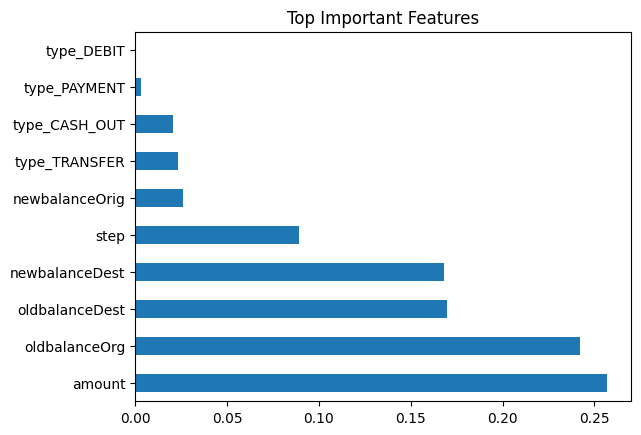

In [26]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind='barh')

plt.title("Top Important Features")
plt.show()

In [27]:
print("🎉 Project Completed Successfully 🚀")

🎉 Project Completed Successfully 🚀


1) Fraud Detection Using Machine Learning
2) Problem Statement
  The goal of this project is to detect fraudulent financial transactions using machine learning techniques and provide actionable insights to prevent fraud.
3) Data Cleaning
- Removed unnecessary columns (nameOrig, nameDest)
- No missing values found
- Converted categorical variables using one-hot encoding
4) Model Description 
Random Forest Classifier is used because it handles large datasets well and provides high accuracy for classification problems.
5)  Feature Selection
Important features were selected based on feature importance such as:
- transaction amount
- balance differences
- transaction type
6) Model Performance 
Model evaluated using:
- Precision
- Recall
- F1 Score
- Confusion Matrix
7)  Key Fraud Factors
- High transaction amount
- Sudden balance drop
- Transfer and Cash-out transactions
8) Do These Factors Make Sense?
Yes, because fraudsters typically transfer large amounts and quickly empty accounts.
9) Prevention Strategy
- Real-time monitoring
- Limit large transactions
- Multi-factor authentication
- AI-based fraud detection system
10) How to Measure Success
- Reduction in fraud cases
- Improved detection rate
- Lower financial losses


